# Forecasting: OLS classica vs Machine Learning

In questa fase confrontiamo una regressione classica non-ML con modelli di Machine Learning per prevedere:

- `unemployment_rate`: tasso di disoccupazione regionale;
- `employed_thousands`: occupati regionali in migliaia.

L'obiettivo non e solo ottenere il numero migliore, ma costruire un confronto corretto e difendibile.

## Strategia di forecasting

Per evitare leakage, le feature usate per prevedere l'anno `t` sono disponibili all'anno `t-1`:

- disoccupazione precedente;
- occupati precedenti;
- PIL precedente;
- log del PIL precedente;
- PIL per occupato precedente;
- NEET precedente;
- regione come variabile categorica.

Il PIL 2025 non e disponibile, quindi per prevedere il 2025 usiamo il PIL 2024. Il test e cronologico: training fino al 2023, valutazione su 2024 e 2025.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from src import modeling, utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Dataset supervisionato per il forecast

In [2]:
samples = {
    "unemployment_rate": utils.build_forecasting_sample("unemployment_rate"),
    "employed_thousands": utils.build_forecasting_sample("employed_thousands"),
}

sample_overview = pd.DataFrame(
    [
        {
            "target": target,
            "rows": len(sample),
            "territories": sample["REF_AREA"].nunique(),
            "year_min": int(sample["year"].min()),
            "year_max": int(sample["year"].max()),
        }
        for target, sample in samples.items()
    ]
)
sample_overview

,target,rows,territories,year_min,year_max
0,unemployment_rate,147,21,2019,2025
1,employed_thousands,147,21,2019,2025


In [3]:
samples["unemployment_rate"].head()

,Territorio,unemployment_rate,year,unemployment_rate_lag1,employed_thousands_lag1,gdp_lag1,log_gdp_lag1,gdp_per_employed_lag1,neet_rate_lag1,REF_AREA
0,Piemonte,7.786975,2019,8.362247,1765.876,135216.6,11.814633,76.571968,17.606570,ITC1
1,Piemonte,7.808230,2020,7.786975,1758.282,135773.8,11.818746,77.219581,16.514095,ITC1
2,Piemonte,7.473577,2021,7.808230,1697.705,124757.0,11.734123,73.485676,20.014564,ITC1
3,Piemonte,6.561637,2022,7.473577,1708.233,137614.9,11.832214,80.559795,19.194039,ITC1
4,Piemonte,6.251766,2023,6.561637,1731.354,146819.8,11.896961,84.800566,15.351761,ITC1


## 2. Modelli confrontati

**Baseline**
- `Naive lag-1`: predice che il valore dell'anno prossimo sara uguale a quello dell'anno precedente.

**Regressione normale senza ML**
- `OLS classica`: regressione lineare con dummy regionali tramite `statsmodels`.

**Machine Learning**
- `Ridge`: modello lineare ML regolarizzato.
- `ElasticNet`: modello lineare ML con regolarizzazione L1/L2.
- `Random Forest`: modello non lineare basato su molti alberi.
- `Gradient Boosting`: modello non lineare sequenziale basato su alberi deboli.

La baseline e fondamentale: se un modello ML non batte la previsione naive, non sta aggiungendo valore reale. Qui distinguiamo anche tra ML lineare e ML non lineare.

In [4]:
train_end_year = 2023
metrics, predictions = modeling.run_all_forecasts(samples, train_end_year=train_end_year)

metrics_path = PROCESSED_DIR / "forecast_metrics.csv"
predictions_path = PROCESSED_DIR / "forecast_predictions.csv"
metrics.to_csv(metrics_path, index=False)
predictions.to_csv(predictions_path, index=False)

metrics

,target,model,n_test,MAE,RMSE,MAPE_%,R2
0,unemployment_rate,Random Forest,42,0.721845,0.951459,14.007192,0.924432
1,unemployment_rate,Gradient Boosting,42,0.739955,0.948016,13.815527,0.924978
2,unemployment_rate,ElasticNet ML lineare,42,0.853724,1.007570,17.703360,0.915256
3,unemployment_rate,Ridge ML lineare,42,0.877046,1.046907,18.811778,0.908510
4,unemployment_rate,OLS classica,42,0.911387,1.201389,17.419801,0.879517
5,unemployment_rate,Naive lag-1,42,0.955963,1.235682,14.854440,0.872541
6,employed_thousands,Naive lag-1,42,12.763524,20.398330,1.164368,0.999609
7,employed_thousands,Gradient Boosting,42,29.704593,48.851868,3.742047,0.997758
8,employed_thousands,Ridge ML lineare,42,31.937242,38.351651,7.453942,0.998618
9,employed_thousands,OLS classica,42,32.448285,40.119569,9.426271,0.998488


## 3. Confronto metriche

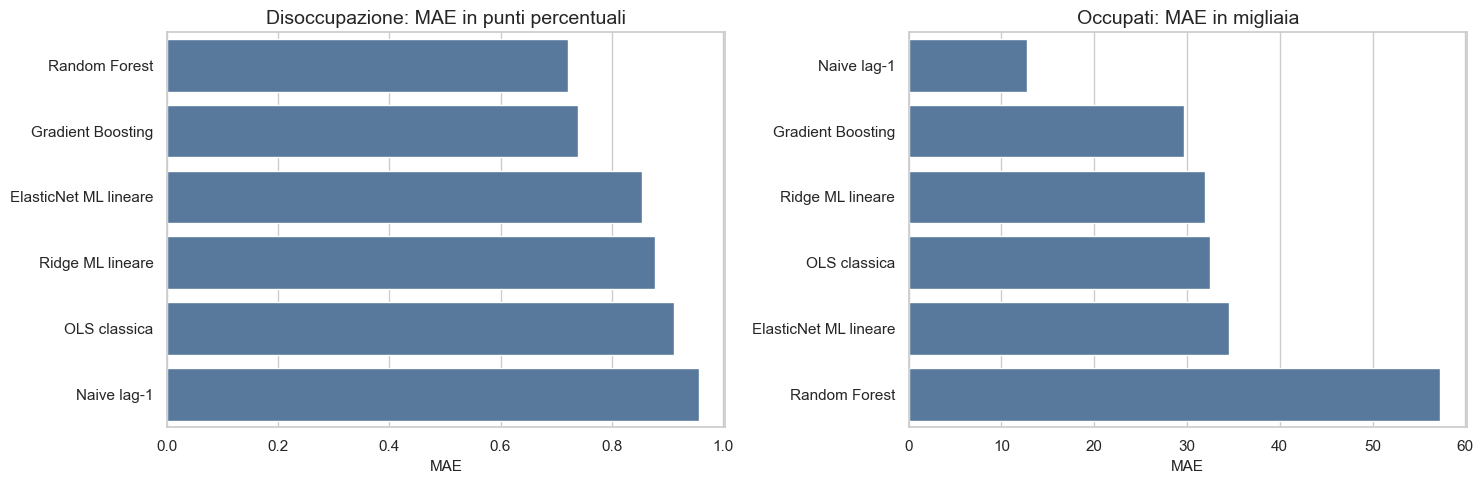

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, target, title in zip(
    axes,
    ["unemployment_rate", "employed_thousands"],
    ["Disoccupazione: MAE in punti percentuali", "Occupati: MAE in migliaia"],
):
    subset = metrics.query("target == @target").sort_values("MAE")
    sns.barplot(data=subset, x="MAE", y="model", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("MAE")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "forecast_mae_comparison.png", dpi=150)
plt.show()

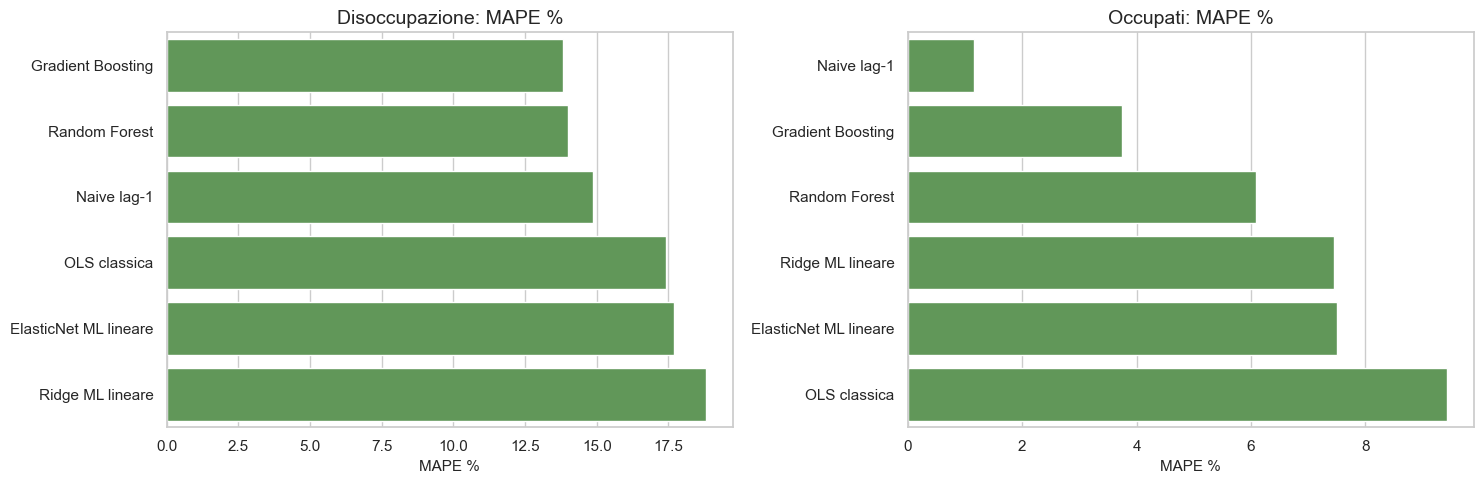

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, target, title in zip(
    axes,
    ["unemployment_rate", "employed_thousands"],
    ["Disoccupazione: MAPE %", "Occupati: MAPE %"],
):
    subset = metrics.query("target == @target").sort_values("MAPE_%")
    sns.barplot(data=subset, x="MAPE_%", y="model", ax=ax, color="#59A14F")
    ax.set_title(title)
    ax.set_xlabel("MAPE %")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "forecast_mape_comparison.png", dpi=150)
plt.show()

## 4. Previsioni vs valori reali

I grafici seguenti mostrano il modello migliore per ogni target secondo MAE sul test 2024-2025.

In [7]:
best_models = metrics.sort_values("MAE").groupby("target").first()["model"].to_dict()
best_models

{'employed_thousands': 'Naive lag-1', 'unemployment_rate': 'Random Forest'}

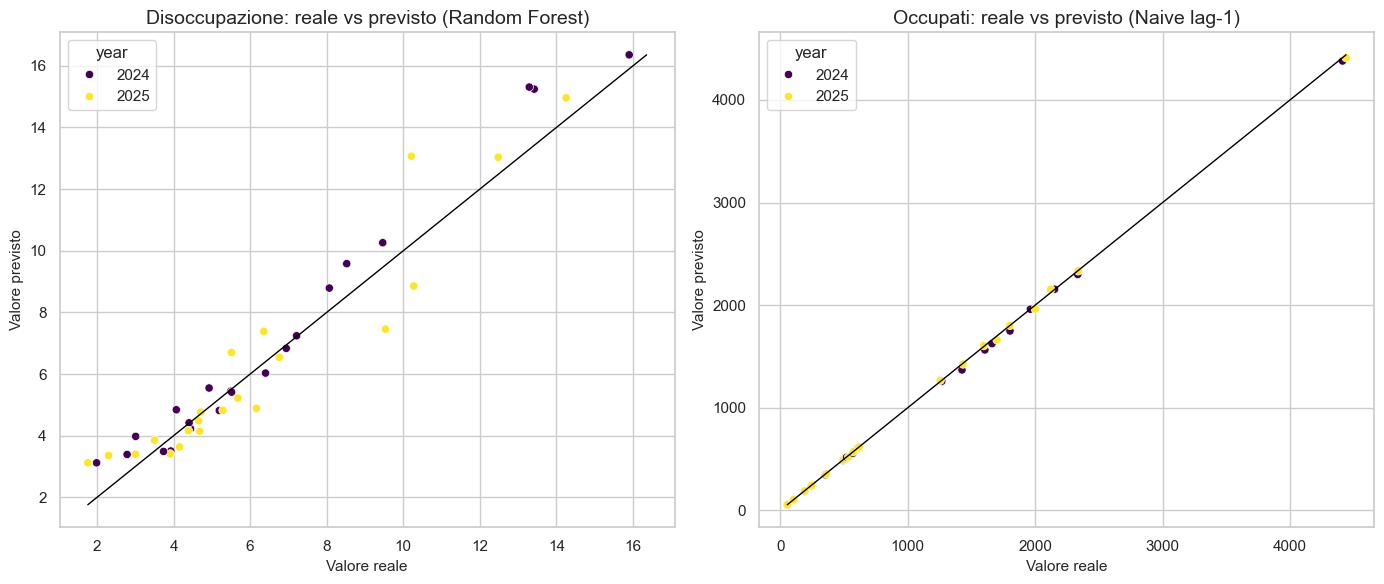

In [8]:
best_predictions = pd.concat(
    [
        predictions.query("target == @target and model == @model_name")
        for target, model_name in best_models.items()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, target, title in zip(
    axes,
    ["unemployment_rate", "employed_thousands"],
    ["Disoccupazione", "Occupati"],
):
    subset = best_predictions.query("target == @target")
    sns.scatterplot(data=subset, x="actual", y="prediction", hue="year", palette="viridis", ax=ax)
    low = min(subset["actual"].min(), subset["prediction"].min())
    high = max(subset["actual"].max(), subset["prediction"].max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set_title(f"{title}: reale vs previsto ({best_models[target]})")
    ax.set_xlabel("Valore reale")
    ax.set_ylabel("Valore previsto")

plt.tight_layout()
plt.savefig(FIG_DIR / "forecast_actual_vs_predicted.png", dpi=150)
plt.show()

## 5. Forecast 2025 e confronto con valori osservati

In [9]:
forecast_2025 = predictions.query("year == 2025").copy()
forecast_2025["error"] = forecast_2025["prediction"] - forecast_2025["actual"]
forecast_2025["abs_error"] = forecast_2025["error"].abs()

forecast_2025.sort_values(["target", "model", "abs_error"]).head(12)

,Territorio,REF_AREA,year,target,model,actual,prediction,error,abs_error
395,Emilia-Romagna,ITD5,2025,employed_thousands,ElasticNet ML lineare,2000.364,2000.541393,0.177393,0.177393
407,Molise,ITF2,2025,employed_thousands,ElasticNet ML lineare,103.595,106.673995,3.078995,3.078995
379,Piemonte,ITC1,2025,employed_thousands,ElasticNet ML lineare,1802.005,1806.799365,4.794365,4.794365
417,Sicilia,ITG1,2025,employed_thousands,ElasticNet ML lineare,1434.241,1442.262283,8.021283,8.021283
413,Basilicata,ITF5,2025,employed_thousands,ElasticNet ML lineare,192.272,200.337381,8.065381,8.065381
381,Valle d'Aosta,ITC2,2025,employed_thousands,ElasticNet ML lineare,55.181,68.125016,12.944016,12.944016
399,Umbria,ITE2,2025,employed_thousands,ElasticNet ML lineare,360.714,380.374361,19.660361,19.660361
409,Campania,ITF3,2025,employed_thousands,ElasticNet ML lineare,1700.347,1672.721323,-27.625677,27.625677
403,Lazio,ITE4,2025,employed_thousands,ElasticNet ML lineare,2337.963,2366.685415,28.722415,28.722415
415,Calabria,ITF6,2025,employed_thousands,ElasticNet ML lineare,536.197,573.776115,37.579115,37.579115


In [10]:
top_2025_errors = (
    forecast_2025.sort_values(["target", "model", "abs_error"], ascending=[True, True, False])
    .groupby(["target", "model"])
    .head(3)
)
top_2025_errors[["target", "model", "Territorio", "actual", "prediction", "error", "abs_error"]]

,target,model,Territorio,actual,prediction,error,abs_error
387,employed_thousands,ElasticNet ML lineare,Bolzano,253.351000,361.515341,108.164341,108.164341
385,employed_thousands,ElasticNet ML lineare,Lombardia,4439.404000,4376.314349,-63.089651,63.089651
405,employed_thousands,ElasticNet ML lineare,Abruzzo,493.869000,556.632903,62.763903,62.763903
475,employed_thousands,Gradient Boosting,Veneto,2122.387000,2276.435929,154.048929,154.048929
479,employed_thousands,Gradient Boosting,Emilia-Romagna,2000.364000,2140.085500,139.721500,139.721500
469,employed_thousands,Gradient Boosting,Lombardia,4439.404000,4353.981599,-85.422401,85.422401
283,employed_thousands,Naive lag-1,Campania,1700.347000,1661.618000,-38.729000,38.729000
269,employed_thousands,Naive lag-1,Emilia-Romagna,2000.364000,1962.454000,-37.910000,37.910000
265,employed_thousands,Naive lag-1,Veneto,2122.387000,2152.548000,30.161000,30.161000
303,employed_thousands,OLS classica,Bolzano,253.351000,342.891361,89.540361,89.540361


## 6. Regressione classica: coefficienti principali

Per la regressione OLS mostriamo i coefficienti delle variabili numeriche. Le dummy regionali sono incluse nel modello, ma non riportate qui per mantenere la tabella leggibile.

In [11]:
ols_tables = []
for target, sample in samples.items():
    train = sample.query("year <= @train_end_year").copy()
    ols_model = smf.ols(modeling.regression_formula(target), data=train).fit()
    coefs = (
        ols_model.params.rename("coef")
        .to_frame()
        .join(ols_model.pvalues.rename("p_value"))
        .reset_index(names="feature")
    )
    coefs = coefs[coefs["feature"].isin(["Intercept", *modeling.NUMERIC_FEATURES])]
    coefs.insert(0, "target", target)
    ols_tables.append(coefs)

ols_coefficients = pd.concat(ols_tables, ignore_index=True)
ols_coefficients

,target,feature,coef,p_value
0,unemployment_rate,Intercept,848.034938,0.001139
1,unemployment_rate,year,-0.395551,0.000751
2,unemployment_rate,unemployment_rate_lag1,0.271819,0.021708
3,unemployment_rate,employed_thousands_lag1,0.001309,0.774286
4,unemployment_rate,log_gdp_lag1,-3.935800,0.505351
5,unemployment_rate,gdp_per_employed_lag1,0.004998,0.951042
6,unemployment_rate,neet_rate_lag1,0.019376,0.764719
7,employed_thousands,Intercept,4201.385441,0.654734
8,employed_thousands,year,-1.271566,0.763071
9,employed_thousands,unemployment_rate_lag1,-2.063206,0.634812


## 7. Interpretazione provvisoria

- Per la disoccupazione i modelli ML tendono a migliorare sia OLS sia baseline naive: questo suggerisce una componente non lineare utile.
- Per gli occupati la baseline lag-1 e molto competitiva: l'occupazione regionale e altamente persistente, quindi un modello complesso deve battere una soglia molto alta.
- Il risultato non va letto come "ML sempre meglio": il confronto con baseline e OLS serve proprio a dimostrare quando il machine learning aggiunge valore e quando no.

Nella prossima fase possiamo rafforzare il progetto con backtesting rolling, feature di macro-area, feature di crescita e una sezione finale di classificazione delle regioni critiche.